In [41]:
import os
from openai import OpenAI

KONG_API_KEY = os.environ["KONG_API_KEY"]

client = OpenAI(
    base_url="https://kong-api.prod1.nyumc.org/gpt-4o/v1.3.0",
    api_key=KONG_API_KEY,
    default_headers={
        "api-key": KONG_API_KEY
    }
)

resp = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "user", "content": "Reply with exactly: i like Optimus Prime"}
    ]
)

print(resp.choices[0].message.content)

i like Optimus Prime


# RAG Optimization — Step-by-Step Benchmark Portal

This notebook runs the baseline and optimized implementations of each RAG component, tracks timings, and visualizes speedups.

**Sections:**
1. Setup — imports, paths, load prebuilt knowledge base
2. Similarity benchmarks — Pure Python vs NumPy vs Numba (single + parallel)
3. Similarity visualization
4. Index benchmarks — BruteForce vs IVF
5. Retrieval quality — Recall@K, MRR
6. Async embedding — Sequential vs Threaded vs Async (simulated API)
7. Async generation — Sequential vs Threaded vs Async (**real Kong gpt-4o**)
8. Summary dashboard

The cell above verifies Kong API connectivity. Run each section in order.

## Section 1 — Setup

Import everything, add the project source directory to `sys.path`, and load the prebuilt knowledge base from `rag-optimization/data/small/`.

All benchmark results are stored in `RESULTS` so later cells can visualize them together.

In [ ]:
# Enable live-reloading of portal.py -- edits there propagate automatically.
%load_ext autoreload
%autoreload 2

import portal

# Change this to "medium" or "large" to run the same benchmarks on a bigger KB.
DATASET = "medium"

portal.setup_cpu_only()
vectors, chunks, queries, data_dir, dataset_name = portal.load_knowledge_base(DATASET)

N, D = vectors[1:].shape        # exclude the vector we'll use as a query

# Global results bucket -- every benchmark writes here. Tagged with dataset + N/D
# so the summary labels plots correctly and Section 8 saves to results/<dataset>.json.
RESULTS = {
    "dataset":           dataset_name,
    "n_vectors":         int(N),
    "dim":               int(D),
    "similarity":        {},
    "index":             {},
    "quality":           {},
    "embedding":         {},
    "generation":        {},   # Section 7 (non-streaming concurrency)
    "generation_stream": {},   # Step 4    (streaming + concurrency, TTFT)
    "pipeline":          {},   # Step 5    (retrieval pool || generation pool)
}

## Section 2 — Similarity benchmarks

Cosine similarity is the **primary optimization target** — it runs for every query against every corpus vector.

Implementations tested:
| Name | File | Technique |
|------|------|-----------|
| Pure Python | `components/similarity.py` | Nested Python loops (intentionally slow baseline) |
| NumPy | `components/similarity.py` | `corpus @ query` — BLAS-backed |
| Numba | `optimized/similarity_numba.py` | `@njit` JIT compilation |
| Numba (parallel) | `optimized/similarity_numba.py` | `@njit(parallel=True)` with `prange` across CPU cores |

**Note:** Pure Python is only timed on a **small subset** (first 500 vectors), otherwise it would take minutes. All others run on the full corpus. The "Pure Python" result is scaled back to the full corpus for fair comparison.

Numba's first call pays a JIT compilation cost — we warm it up before timing.

In [43]:
RESULTS["similarity"] = portal.run_similarity_benchmarks(vectors)

Corpus: N=99999, D=384
Warming up Numba JIT...
Numba JIT warmup complete.
NumPy            :   55.783 +/- 1.116 ms
Numba            :   39.119 +/- 0.446 ms
Numba (parallel) :    5.839 +/- 0.111 ms
Pure Python      :   71.254 ms on 500 vecs  ->  ~14250.7 ms extrapolated to 99999

Correctness vs NumPy:
  Numba                max|diff| = 7.37e-08  OK
  Numba (parallel)     max|diff| = 7.37e-08  OK
  Pure Python (subset) max|diff| = 2.98e-07  OK

Summary (speedup vs NumPy):
  Pure Python (extrapolated)      14250.684 ms     0.00x
  NumPy                              55.783 ms     1.00x
  Numba                              39.119 ms     1.43x
  Numba (parallel)                    5.839 ms     9.55x


## Section 3 — Similarity visualization

Two plots side by side:
- **Left:** mean latency per implementation (log scale — needed to show Pure Python on the same axis)
- **Right:** speedup vs NumPy (NumPy = 1.0x reference line)

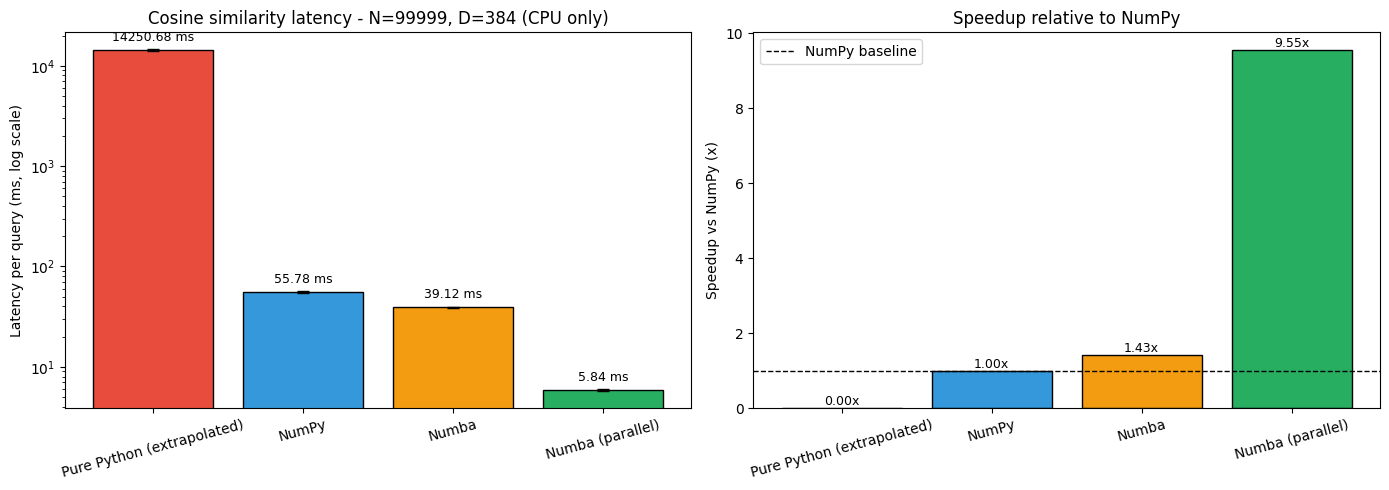


Speedup vs Pure Python (the interpreted-Python baseline):
  Pure Python (extrapolated)          1.0x
  NumPy                             255.5x
  Numba                             364.3x
  Numba (parallel)                 2440.5x


In [44]:
portal.plot_similarity(RESULTS["similarity"], N, D)

## Section 4 — Index benchmarks (BruteForce vs IVF)

Section 2 optimized *how* we compute similarity. This section optimizes *which vectors we compare against at all* — a structural optimization.

| Index | Build cost | Query cost | Recall |
|-------|-----------|-----------|--------|
| **BruteForceIndex** | near zero (just stores vectors) | O(N · D) — compares against **every** vector | 100% by definition |
| **IVFIndex** | K-Means clustering up front | O(n_probes · N/K · D) — only searches nearest clusters | ≤ 100% (tunable via `n_probes`) |

**Parallel build** (`optimized/parallel_indexer.py`) uses multiprocessing + shared memory for the cluster-assignment step. K-Means itself is still sequential, so Amdahl's law limits the speedup — and on a 5K-vector dataset, process-spawning overhead may even make it *slower*. We test honestly either way.

Two things measured here:
1. **Build time** — sequential IVF vs parallel IVF
2. **Query time** — BruteForce vs IVF at several `n_probes` values (1, 2, 4, 8 out of 32 clusters)

Recall quality is verified in Section 5.

In [102]:
# Step 3: Numba K-Means + K-Means++ initialization.
#   kmeans_impl choices:
#     "baseline" -> original pure-NumPy K-Means with random init       (step 0 / step 1)
#     "numba"    -> Numba-accelerated K-Means with random init         (step 2)
#     "numba_pp" -> Numba-accelerated K-Means with K-Means++ init      (step 3)
N_CLUSTERS  = 64
KMEANS_IMPL = "numba_pp"

bf, ivf_seq, ivf_par, RESULTS["index"]["build"] = portal.run_index_build_benchmarks(
    vectors, chunks, n_clusters=N_CLUSTERS, kmeans_impl=KMEANS_IMPL
)

Warming up Numba K-Means JIT...
  Numba K-Means warmup complete.
Corpus: N=100000, D=384, clusters=64, kmeans=numba_pp
BruteForceIndex built: 100000 vectors in 0.025s
Building IVF index: 100000 vectors, 64 clusters...
    [Numba] running K-Means++ init for 64 centroids...
    [Numba] K-Means++ init done in 510 ms
    [Numba] K-Means iter 5/20, shift=0.325049
    [Numba] K-Means iter 10/20, shift=0.146146
    [Numba] K-Means iter 15/20, shift=0.079666
    [Numba] K-Means iter 20/20, shift=0.059691
IVF index built in 2.08s
  Cluster sizes: min=601, max=3503, mean=1562, std=624
Running K-Means with 64 clusters...
    [Numba] running K-Means++ init for 64 centroids...
    [Numba] K-Means++ init done in 465 ms
    [Numba] K-Means iter 5/20, shift=0.325049
    [Numba] K-Means iter 10/20, shift=0.146146
    [Numba] K-Means iter 15/20, shift=0.079666
    [Numba] K-Means iter 20/20, shift=0.059691
Parallel assignment with 4 workers...
Parallel IVF build complete: 2.43s (4 workers)

--- Build ti

In [103]:
RESULTS["index"]["query"] = portal.run_index_query_benchmarks(
    bf, ivf_seq, vectors, k=10, probes=(2, 4, 8, 16)
)

BruteForce (NumPy)       :  57.804 +/- 0.978 ms/query
IVF n_probes=2          :   3.566 +/- 0.088 ms/query   (16.21x vs BruteForce)
IVF n_probes=4          :   6.781 +/- 0.046 ms/query   ( 8.52x vs BruteForce)
IVF n_probes=8          :  12.987 +/- 0.076 ms/query   ( 4.45x vs BruteForce)
IVF n_probes=16         :  26.887 +/- 0.277 ms/query   ( 2.15x vs BruteForce)


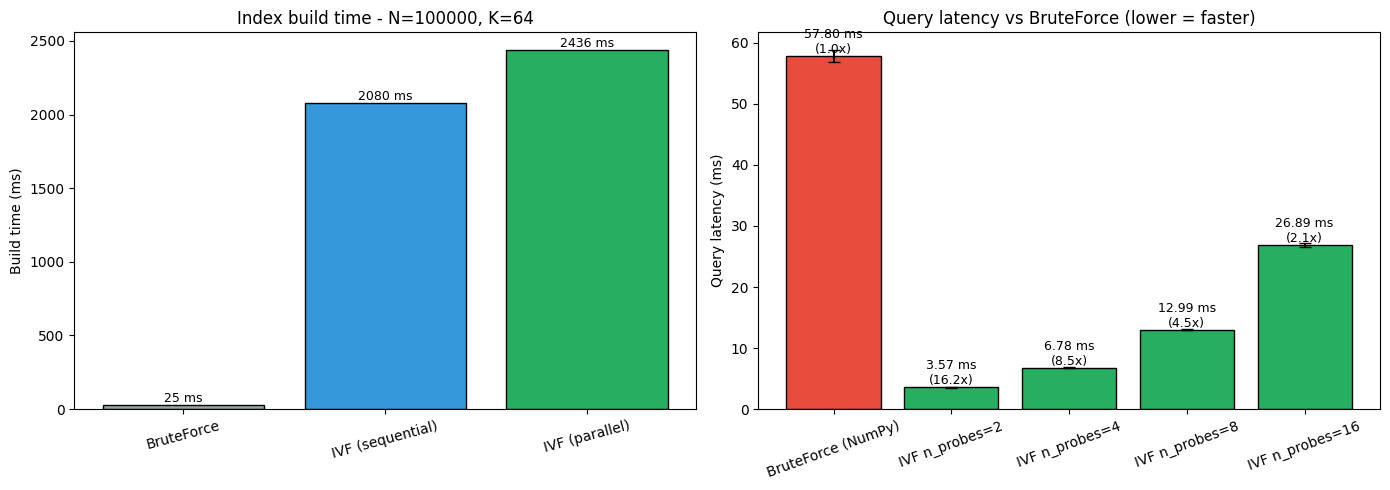


Higher n_probes -> slower query but higher recall (verified in Section 5).


In [104]:
portal.plot_index(RESULTS["index"]["build"], RESULTS["index"]["query"], N=len(vectors), n_clusters=N_CLUSTERS)

## Section 5 — Retrieval quality (Recall@K, MRR)

Section 4 showed IVF is much faster than BruteForce. But **a fast wrong answer is useless.** This section verifies how much recall IVF sacrifices.

**Metrics:**
- **Recall@K** — fraction of the query's relevant passages that appear in the top-K retrieved chunks.
- **MRR** — mean reciprocal rank of the first relevant chunk (higher = relevant docs come up sooner).

**Methodology:**
- Use MS MARCO queries with relevance judgments
- Embed each query on CPU with the same `all-MiniLM-L6-v2` model that built the corpus
- For each (index, config), run the query and compare the retrieved chunks' **source passage text** against `relevant_passages`
- BruteForce is the ground-truth reference — its Recall@K sets the ceiling

The third chart — **Recall vs Latency** — is the speed/quality Pareto frontier, the picture you put in a report.

In [105]:
RESULTS["quality"] = portal.run_retrieval_quality(
    vectors, chunks, queries, data_dir,
    bf=bf, ivf=ivf_seq,
    k=10, probes=(2, 4, 8, 16),
)

Evaluating on 500 queries with relevance judgments.
Embedding query texts (CPU)...
Loading embedding model: all-MiniLM-L6-v2 (device=cpu)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7222.61it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  embedded 500 queries in 1920 ms
Running BruteForce (ground truth)...
Running IVF n_probes=2...
Running IVF n_probes=4...
Running IVF n_probes=8...
Running IVF n_probes=16...

Config                   Recall@K        MRR   Lat (ms)    % of BF
----------------------------------------------------------------------
BruteForce                 0.8908     0.4937     58.501     100.0%
IVF n_probes=2             0.7442     0.4270      4.110      83.5%
IVF n_probes=4             0.8178     0.4577      7.734      91.8%
IVF n_probes=8             0.8478     0.4754     14.461      95.2%
IVF n_probes=16            0.8728     0.4872     28.942      98.0%


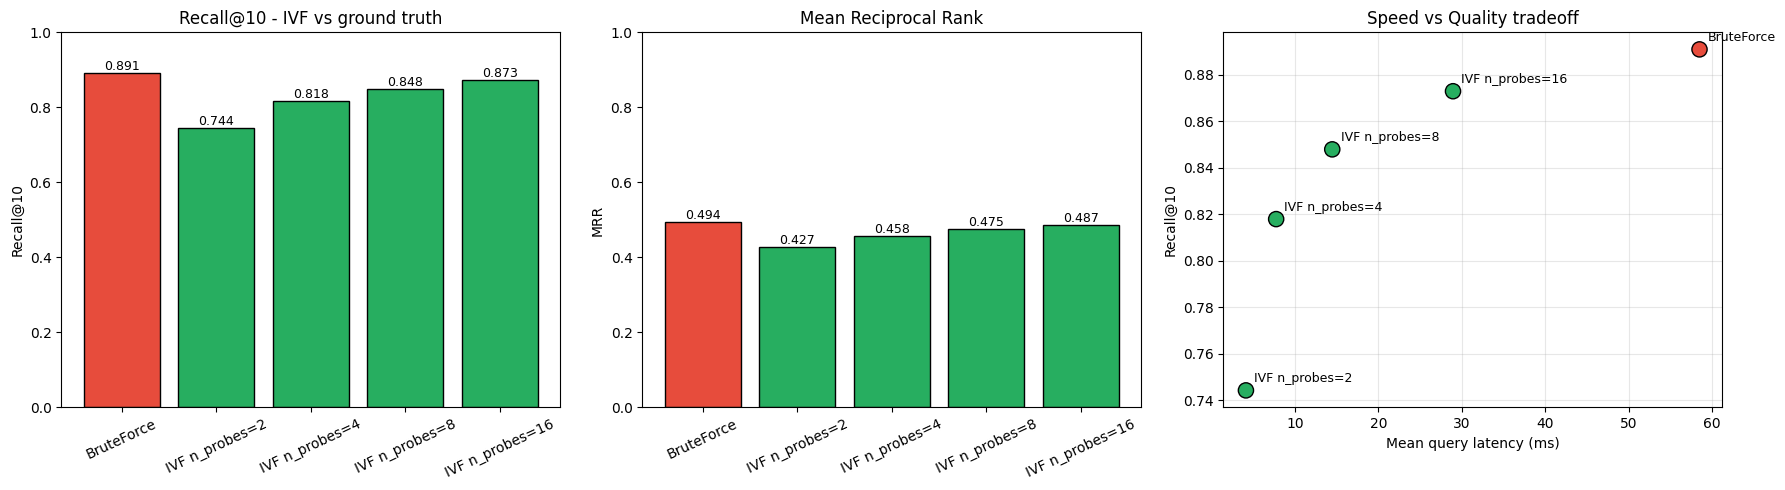

In [106]:
portal.plot_retrieval_quality(RESULTS["quality"], k=10)

## Section 6 — Async embedding (IO-bound concurrency)

Sections 2–5 optimized **CPU-bound** work (similarity math, clustering). This section is different: it optimizes **IO-bound** work — specifically, waiting for an embedding API to respond.

The baseline embeds batches sequentially:
```
Batch 1 → wait 100ms → done
Batch 2 → wait 100ms → done   (starts only after 1 finishes)
...
N batches × 100ms = N × 100ms total
```

Because each batch spends ~100 ms waiting on network IO (not CPU), we can fire many batches concurrently. The right tool here is **threading or asyncio**, NOT multiprocessing (the GIL is not the problem — we're already idle during IO).

**Setup:** simulated API with `100 ms` per batch, `batch_size=64`, **640 texts = 10 batches**.

**Ideal outcomes:**
- Sequential: 10 × 100 ms = **~1000 ms**
- Threaded/Async (10+ workers): all batches run in parallel = **~100 ms** (≈10× speedup)

We use simulated latency instead of a real endpoint here because it makes the speedup easy to reason about and doesn't burn API credits. The pattern is identical for a real API.

In [64]:
RESULTS["embedding"] = portal.run_async_embedding_benchmarks(
    chunks,
    n_texts=640,
    batch_size=64,
    simulated_latency_ms=100.0,
    n_threads=10,
    max_async=16,
)

Embedding 640 texts  |  batch_size=64  |  10 batches  |  100 ms/batch
Ideal sequential: 1000 ms
Ideal concurrent: ~100 ms (all batches in parallel)

Sequential          :   1113.5 ms
Threaded (n=10)      :    231.9 ms   ( 4.80x vs sequential)
Async (max=16)       :    227.4 ms   ( 4.90x vs sequential)


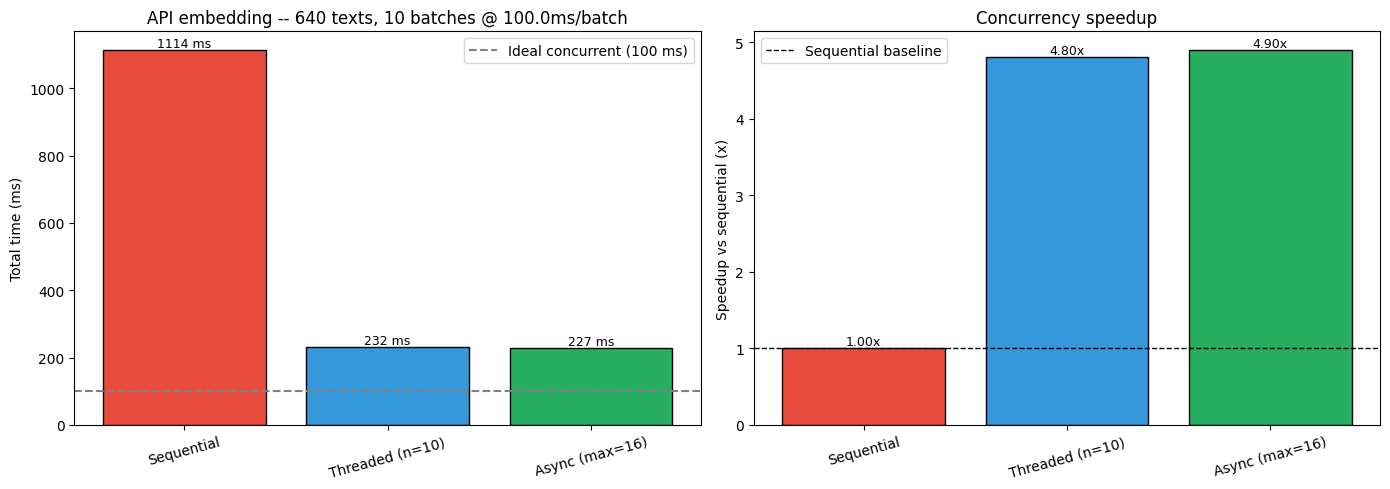

In [65]:
portal.plot_async_embedding(RESULTS["embedding"])

## Section 7 — Async generation (real Kong gpt-4o)

Section 6 used a simulated API. This section hits the **real gpt-4o endpoint** through NYU's Kong proxy — the same endpoint verified at the top of the notebook.

**What this tests:** The final step of a RAG pipeline. For each query:
1. Embed the query text (already done)
2. Retrieve top-3 chunks from the BruteForce index (already built)
3. Send `(query + contexts)` to gpt-4o and wait for the answer

Real LLM calls typically take **500–2000 ms each**. If we issue N queries sequentially that's N seconds; if we fire them concurrently they all wait at the same time → roughly one call's latency for the whole batch.

**Configuration:**
- 8 real queries (keep API cost low — about $0.05–0.10 per full run)
- `max_tokens=128` (short answers, keeps latency snappy)
- Threaded: 8 workers
- Async: 8 max concurrent

**Expected outcome:**
- Sequential: N × single-call latency (e.g., 8 × 1.2 s ≈ 10 s)
- Threaded / Async: ~single-call latency (e.g., ~1.5 s) → **5–8× speedup**

Real-world variability is higher than the simulated test because actual LLM latency jitters with token count, load, and network.

In [66]:
# Build real (query, top-3 contexts) pairs using the BruteForce index.
GEN_ITEMS = portal.prepare_generation_items(queries, chunks, bf=bf, n_items=8, k=3)

Embedding 8 queries for retrieval (CPU)...
Loading embedding model: all-MiniLM-L6-v2 (device=cpu)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7395.34it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prepared 8 (query, contexts) pairs. Sample query: 'what is rba'


In [67]:
# WARNING: this cell makes 24 real Kong gpt-4o calls total (8 per method x 3 methods).
RESULTS["generation"] = portal.run_async_generation_benchmarks(
    GEN_ITEMS,
    n_threads=8,
    max_async=8,
    model="gpt-4o",
    max_tokens=128,
)


[1/3] Sequential : sending 8 real API calls one-by-one...
      total:  11094.0 ms   (mean per call: 1386.7 ms)
[2/3] Threaded   : firing 8 calls with 8 threads...
      total:   2093.2 ms   ( 5.30x vs sequential)
[3/3] Async      : firing 8 calls with max_concurrent=8...
      total:   2216.7 ms   ( 5.00x vs sequential)

Sample answer (first query):
  Q: what is rba
  A: The context provides information about two different entities or concepts referred to as RBA:

1. In Document 1, RBA is described as a digital and technology consultancy that focuses on strategy, desi


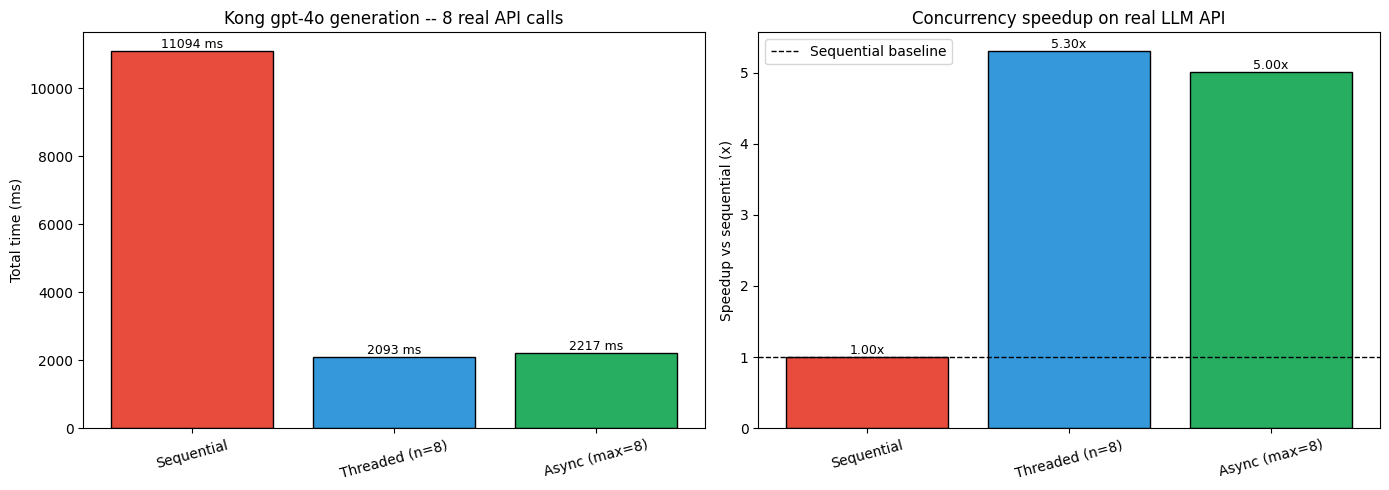

In [68]:
portal.plot_async_generation(RESULTS["generation"])

---

## Step 4 — LLM streaming (Week 9 concurrency, TTFT metric)

Section 7 optimized **batch throughput** (fire N calls in parallel, finish all faster). Step 4 optimizes **perceived latency**: when does the FIRST TOKEN arrive?

A user of a chat UI doesn't care that the full answer takes 1.5 s — they care that the answer *starts appearing* as soon as possible. With `stream=True` we get tokens as the model generates them. For a 128-token response, the first token typically arrives ~150-400 ms after the request is sent, even though the full response still takes ~1.5 s.

Three modes compared on **real Kong gpt-4o calls**:

| Mode | Batch total | Per-call TTFT | Notes |
|------|------------|---------------|-------|
| Sequential, non-streaming | 8 × 1.5 s = 12 s | ≈ 1500 ms | Section 7 baseline |
| Sequential, streaming | 8 × 1.5 s = 12 s | **~200 ms** | Same total, 7× lower perceived latency |
| Concurrent, streaming | ~1.5-2 s | ~200 ms | **Best of both** — fast batch + instant per-user response |

We reuse `GEN_ITEMS` built in Section 7 (no re-embedding needed). Total cost: 24 real API calls (~$0.08).

In [112]:
# WARNING: makes 24 real Kong gpt-4o calls (8 per mode x 3 modes). ~$0.08.
RESULTS["generation_stream"] = portal.run_streaming_generation_benchmarks(
    GEN_ITEMS,
    model="gpt-4o",
    max_tokens=128,
    concurrent_workers=8,
)


[1/3] Sequential NON-streaming : 8 real calls, one by one...
      batch total: 13908 ms | mean TTFT: 1738 ms
[2/3] Sequential STREAMING     : same 8 calls, stream=True...
      batch total: 10933 ms | mean TTFT: 961 ms  (TTFT -45%)
[3/3] CONCURRENT streaming     : 8 calls, 8 workers, stream=True...
      batch total: 2421 ms | mean TTFT: 1158 ms

Sample non-streaming answer (first query):
  A: The context provided mentions two different entities with the acronym "RBA":

1. RBA is described as a digital and technology consultancy focused on strategy, design, and technology, helping companies


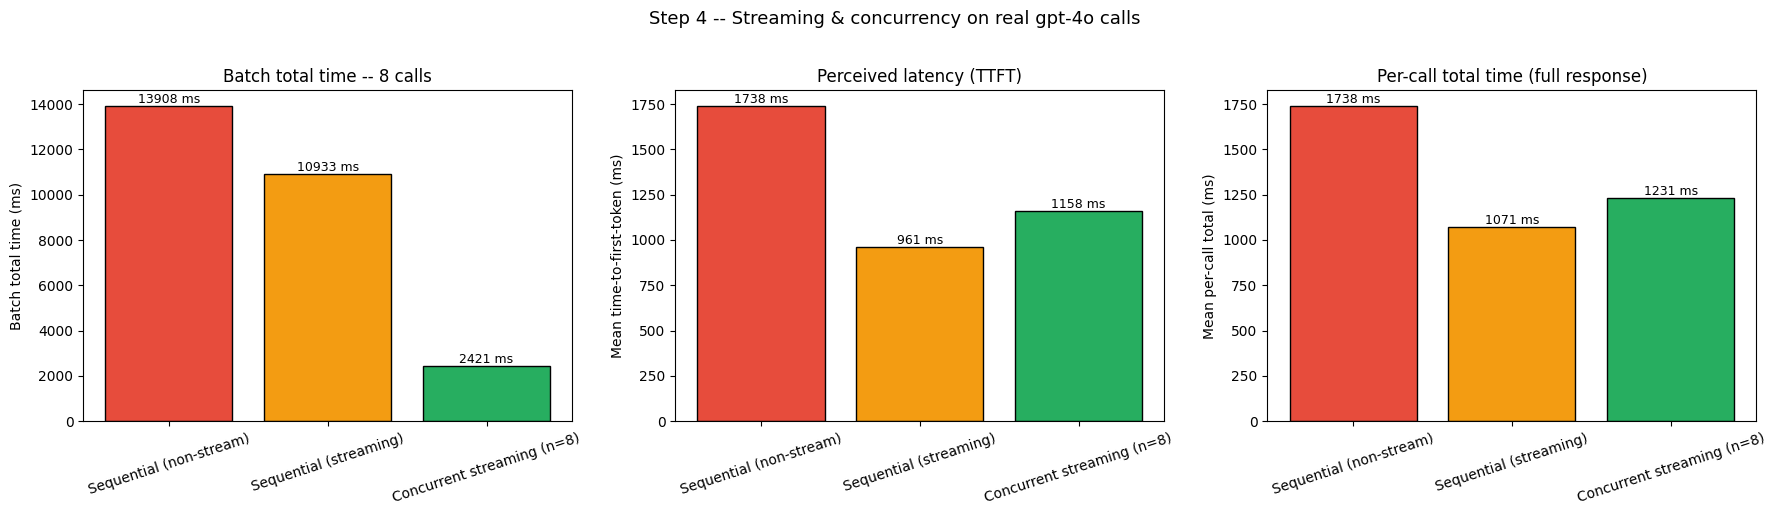

In [113]:
portal.plot_streaming_generation(RESULTS["generation_stream"])

---

## Step 5 — Pipelined RAG (Week 10/11 parallel programming)

Previous steps optimized individual stages (similarity, index, embedding, generation). Step 5 optimizes **how the stages compose**.

Compare two end-to-end RAG serving patterns on real Kong gpt-4o (N=8 queries):

| Pattern | Structure | Total time |
|---------|-----------|------------|
| **Sequential (naive)** | For each query: embed → search → gen, one at a time | N × (embed + search + gen) |
| **Pipelined** | Two thread pools: retrieval (4 workers) + generation (8 workers). Each retrieval future *submits* its result to the gen pool from within the retrieval worker, so stages overlap. | ~ max(retrieval, gen_concurrent) |

**The trick:** inside each retrieval worker, as soon as embed+search finishes, it hands off `(query, contexts)` to the generation pool. Retrieval of query `i+1` runs on another retrieval worker while generation of query `i` is streaming from gpt-4o. CPU (retrieval) and network IO (generation) are saturated simultaneously.

**Note:** the sequential baseline uses per-query embedding (no batch), simulating a realistic streaming-query scenario where queries arrive independently. This is the honest comparison for Week 10/11 — not to beat Section 7 (which benefits from batch embedding), but to show how pipeline architecture saves the per-query serial cost.

In [116]:
# WARNING: makes ~16 real Kong gpt-4o calls (8 sequential + 8 pipelined). ~$0.06.
RESULTS["pipeline"] = portal.run_pipeline_benchmarks(
    queries, chunks, bf,
    n_items=8,
    k=3,
    n_embed_workers=4,
    n_gen_workers=8,
    model="gpt-4o",
    max_tokens=128,
)


[1/2] Sequential (naive): 8 queries, one at a time (embed -> search -> gen_stream)...
Loading embedding model: all-MiniLM-L6-v2 (device=cpu)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7792.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


      total: 14456 ms   (1807 ms/query)
[2/2] Pipelined: retrieve pool (n=4) + gen pool (n=8), overlapping stages...
      total: 2817 ms   (352 ms/query)   5.13x vs sequential


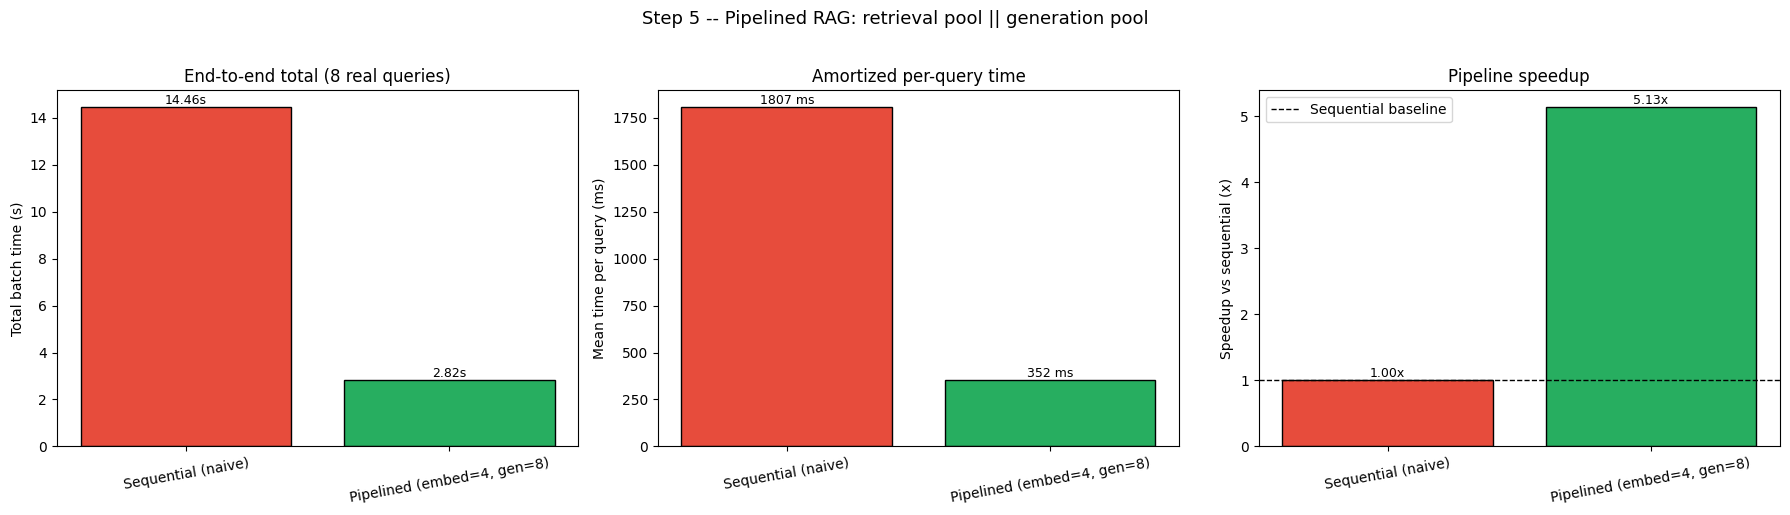

In [117]:
portal.plot_pipeline(RESULTS["pipeline"])

## Section 8 — Summary dashboard

Pull the headline result from each section into one view:

- Section 2 — cosine similarity: Pure Python / NumPy / Numba / Numba parallel
- Section 4 — index query: BruteForce vs IVF across n_probes values
- Section 5 — speed/quality Pareto frontier (Recall@10 vs latency)
- Section 6 — simulated API embedding: Sequential vs Threaded vs Async
- Section 7 — real gpt-4o generation: Sequential vs Threaded vs Async
- **End-to-end scenario** — combining the best choice from each section for a batch of 8 RAG queries

The end-to-end speedup is the number that belongs in your report conclusion.

In [107]:
portal.print_summary(RESULTS)

  RAG Optimization Benchmark Summary -- dataset=medium, N=99999, D=384 (CPU only)

[Section 2] Cosine similarity (per query, dataset=medium, N=99999, D=384)
  Pure Python baseline:    14250.68 ms
  NumPy baseline:             55.78 ms   ( 255.5x vs Python)
  Best: Numba (parallel)                5.84 ms   (2440.5x vs Python, 9.55x vs NumPy)

[Section 4] Index search (per query)
  BruteForce:                57.804 ms
  Best: IVF n_probes=2                 3.566 ms   (16.21x vs BruteForce)

[Section 5] Retrieval quality (Recall@10)
  BruteForce (ceiling):  0.8908
  IVF n_probes=2            0.7442   (83.5% of BF ceiling, 4.11 ms/query)
  IVF n_probes=4            0.8178   (91.8% of BF ceiling, 7.73 ms/query)
  IVF n_probes=8            0.8478   (95.2% of BF ceiling, 14.46 ms/query)
  IVF n_probes=16           0.8728   (98.0% of BF ceiling, 28.94 ms/query)

[Section 6] API embedding (10 simulated batches @ 100.0 ms/batch)
  Sequential:                1113.5 ms
  Best: Async (max=16)      

d:\Zhihuan Hao Important Documents\NYU Grad Study Materials\Spring 2026\Advanced Python\Retrieval-Augmented-Generation-Optimization-Test\portal.py:982: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f"  TOTAL                   : {base_total:6.3f} s",


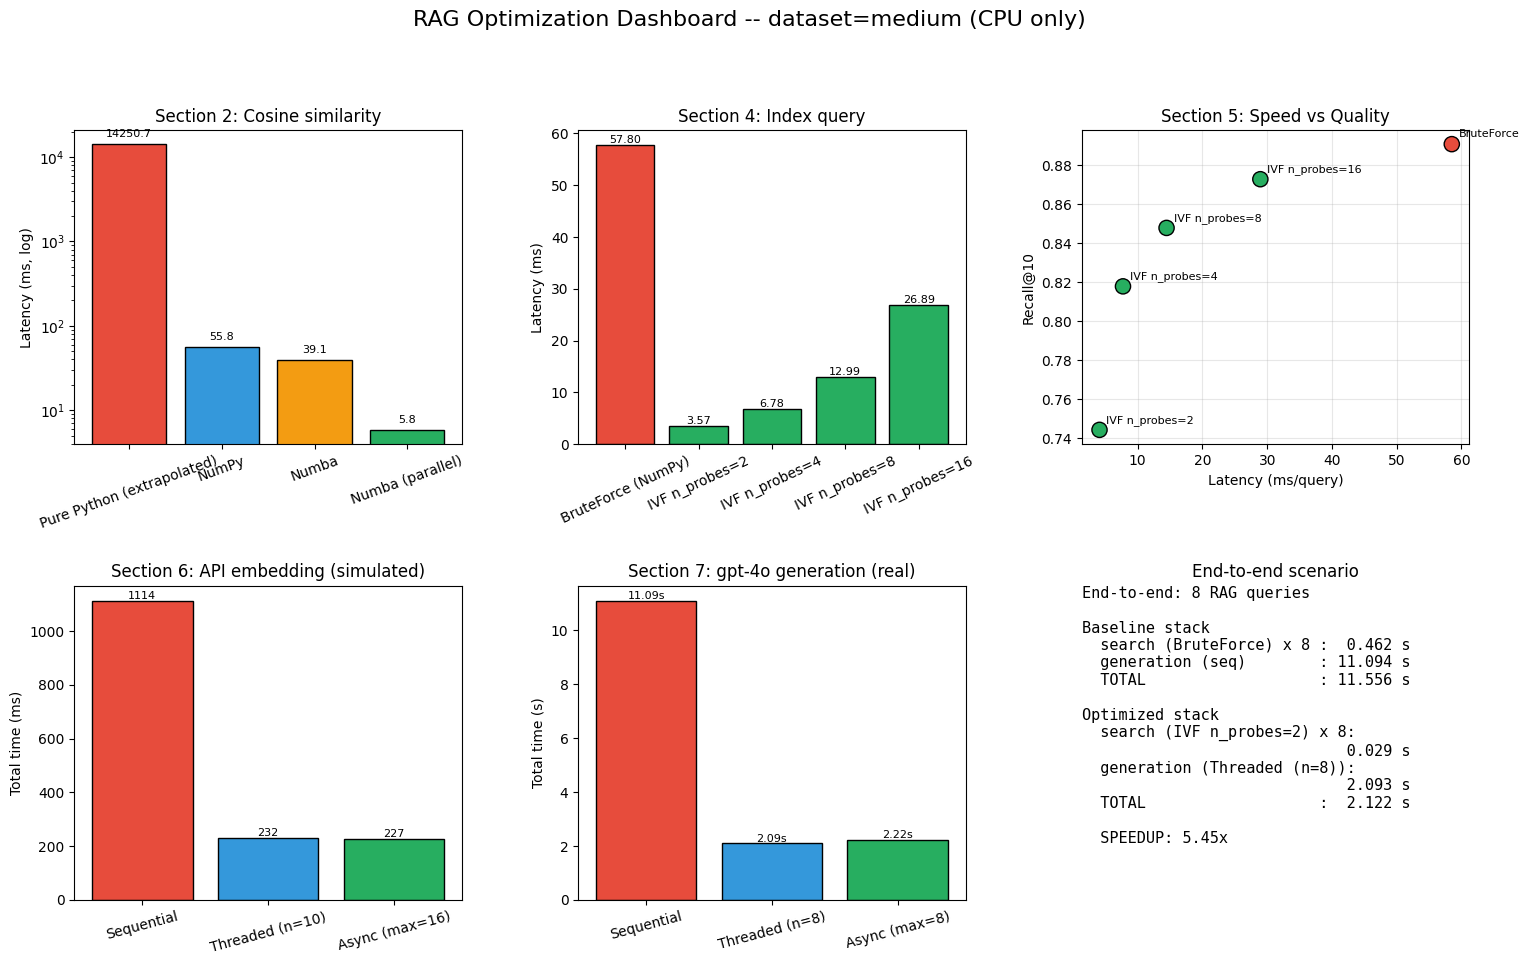

In [108]:
portal.plot_summary(RESULTS)

In [ ]:
# # Save RESULTS to results/<dataset>.json (overwrites on each run so the file
# # always reflects the latest run for that dataset size).
# saved_path = portal.save_results(RESULTS)

# # Show all saved runs across dataset sizes
# print("\nAll saved benchmark runs:")
# for dataset, saved_at, path in portal.list_saved_results():
#     print(f"  {dataset:<8}  {saved_at}  -> {path}")

Saved: D:\Zhihuan Hao Important Documents\NYU Grad Study Materials\Spring 2026\Advanced Python\Retrieval-Augmented-Generation-Optimization-Test\results\medium.json  (4.7 KB)

All saved benchmark runs:
  medium    2026-04-16 17:04:42  -> d:\Zhihuan Hao Important Documents\NYU Grad Study Materials\Spring 2026\Advanced Python\Retrieval-Augmented-Generation-Optimization-Test\results\medium.json


---

## Optimization tracking — incremental record-keeping

Each time we apply an optimization, we save the current `RESULTS` as a **tagged experiment snapshot** to `results/experiments/<dataset>_<step>.json`. Nothing is ever overwritten, so every historical step is preserved.

**Workflow per optimization:**
1. Change the code/parameter
2. Re-run all sections (top to bottom) to get a fresh `RESULTS`
3. Edit `STEP`, `STEP_DESC`, `STEP_PARENT` below and run the save cell
4. Run the comparison cell to see before/after deltas

**Suggested optimization roadmap (each saved as its own step):**

| Step | Name | What changes |
|------|------|--------------|
| `0_baseline` | — | Original code (IVF 32 clusters) |
| `1_ivf_tuned` | IVF parameter tuning | `N_CLUSTERS = 64` — match `sqrt(N)` rule for medium |
| `2_kmeans_numba` | Numba-accelerated K-Means | Rewrite `_kmeans` update step with `@njit` |
| `3_kmeans_pp_init` | K-Means++ initialization | Smarter centroid seeding, faster convergence |
| `4_llm_streaming` | Streaming gpt-4o | Measure TTFT instead of total latency |
| `5_two_stage` | Two-stage retrieval | Fast IVF recall + exact re-rank |

Code changes between steps should also be committed to Git so you can reconstruct the exact source state of each step.

In [118]:
# ----- Save the current run as a tagged optimization step -----
# Edit these 3 variables before running, then execute.
STEP        = "5_pipeline"
STEP_DESC   = "Pipelined RAG: retrieval pool (4) || generation pool (8), overlapping stages"
STEP_PARENT = "4_llm_streaming"





portal.save_experiment(RESULTS, step_name=STEP,
                       description=STEP_DESC, parent=STEP_PARENT)

print("\n--- All experiments for this dataset ---")
portal.print_experiments(dataset=RESULTS["dataset"])

Saved experiment: medium_5_pipeline.json  (7.4 KB)
  parent: 4_llm_streaming
  description: Pipelined RAG: retrieval pool (4) || generation pool (8), overlapping stages

--- All experiments for this dataset ---
Step                      Parent          Saved at             Description
----------------------------------------------------------------------------------------------------
0_baseline                -               2026-04-16 17:26:29  Original pipeline: IVF n_clusters=32, probes=(1,2,4,8), rand
1_ivf_tuned               0_baseline      2026-04-16 17:41:09  IVF n_clusters=32 -> 64, probes = (2,4,8,16) for equal corpu
2_kmeans_numba            1_ivf_tuned     2026-04-16 17:52:13  Numba-compiled K-Means update step + hoisted vector norms
3_kmeans_pp_init          2_kmeans_numba  2026-04-16 18:07:35  K-Means++ seeding instead of random -- faster convergence, b
4_llm_streaming           3_kmeans_pp_init 2026-04-16 18:25:11  Streaming responses (stream=True) -- TTFT -45% seq, conc

  Experiment diff  (medium)   4_llm_streaming  -->  5_pipeline
    4_llm_streaming: Streaming responses (stream=True) -- TTFT -45% seq, concurrent streaming batch 5.7x vs non-stream baseline
    5_pipeline: Pipelined RAG: retrieval pool (4) || generation pool (8), overlapping stages
Metric                    4_llm_streaming         5_pipeline        Delta        %
------------------------------------------------------------------------------------
bf_query_ms                       57.8040            57.8040      +0.0000   +0.0% =
emb_best_ms                      227.4462           227.4462      +0.0000   +0.0% =
emb_seq_ms                      1113.5407          1113.5407      +0.0000   +0.0% =
gen_best_ms                     2093.2440          2093.2440      +0.0000   +0.0% =
gen_seq_ms                     11093.9862         11093.9862      +0.0000   +0.0% =
ivf_best_cfg               IVF n_probes=2     IVF n_probes=2
ivf_best_ms                        3.5664             3.5664      +

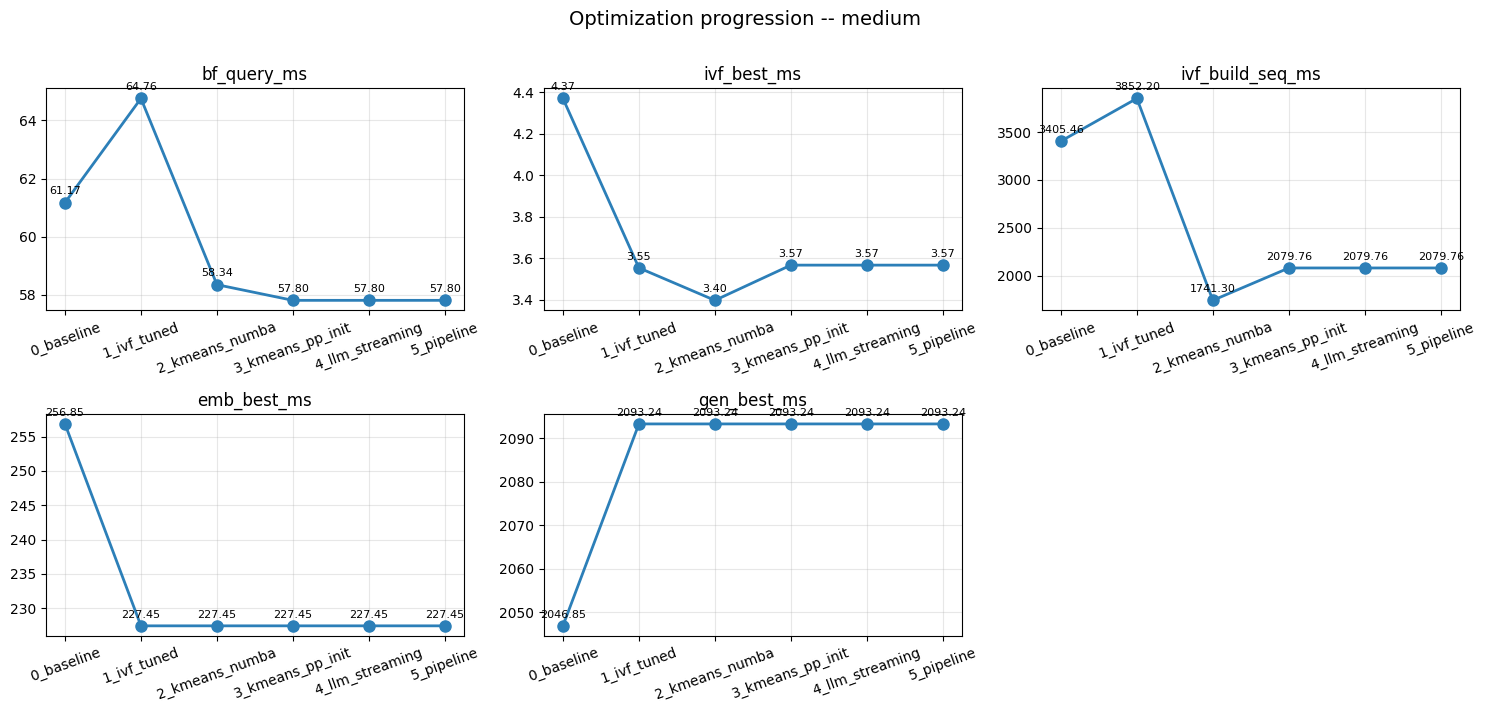

In [119]:
# ----- Compare any two saved steps, and plot progression across all steps -----
# After you save the next step, compare to the previous one.
STEP_FROM = "4_llm_streaming"
STEP_TO   = "5_pipeline"

# set this to the latest step to see the delta

if STEP_FROM != STEP_TO:
    portal.compare_experiments(RESULTS["dataset"], STEP_FROM, STEP_TO)
else:
    print(f"(STEP_FROM == STEP_TO == '{STEP_FROM}' -- nothing to diff yet.)")

# Multi-step progression plot (auto-includes all experiments saved for this dataset)
portal.plot_experiment_progression(RESULTS["dataset"])